In [11]:
import jax
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt

In [12]:
A = jnp.diag(jnp.array([1.0, 100.0]))

In [13]:
def loss(theta):
    return (0.5) * (theta @ (A @ theta))

def grad(theta):
    return theta @ A

def step_gd(theta, lr):
    g = grad(theta)
    update = -lr * g
    return theta+update, update

def step_sgd(theta, lr, key, sigma):
    g = grad(theta)
    eps = sigma * random.normal(key, shape=theta.shape)
    g_noisy = g + eps
    update = -lr * g_noisy 
    return theta+update, update

def step_minibatch_sgd(theta, lr, key, sigma, k):
    g = grad(theta)
    keys = random.split(key, k)
    eps = sigma * jax.vmap(lambda kk: random.normal(kk, shape=theta.shape))(keys)
    eps_mean = eps.mean(axis=0)
    g_noisy = g + eps_mean
    update = -lr * g_noisy
    return theta+update, update

In [14]:
def run_experiment(seed=0, steps=200, lr=0.015, theta0=jnp.array([4.0, 4.0]), sigma=2.5, minibatch_ks=(1, 4, 16, 64)):
    key = random.PRNGKey(seed)

    theta = theta0
    thetas_gd = [theta]
    losses_gd = [loss(theta)]
    upd_norms_gd = [0.0]

    for t in range(steps):
        theta, update = step_gd(theta, lr)
        thetas_gd.append(theta)
        losses_gd.append(loss(theta))
        upd_norms_gd.append(float(jnp.linalg.norm(update)))

    # Mini-batch SGD trajectories
    mb_results = {}
    for k in minibatch_ks:
        theta = theta0
        thetas = [theta]
        losses_list = [loss(theta)]
        upd_norms = [0.0]

        for t in range(steps):
            key, subkey = random.split(key)
            theta, update = step_minibatch_sgd(theta, lr, subkey, sigma, k)
            thetas.append(theta)
            losses_list.append(loss(theta))
            upd_norms.append(float(jnp.linalg.norm(update)))
        
        mb_results[k] = {
            "thetas": jnp.array(thetas),
            "losses": jnp.array(losses_list),
            "upd_norms": jnp.array(upd_norms),
        }

    return {
        "gd": {
            "thetas": jnp.array(thetas_gd),
            "losses": jnp.array(losses_gd),
            "upd_norms": jnp.array(upd_norms_gd),
        },
        "minibatch": mb_results,
        "config": {
            "seed": seed, 
            "steps": steps, 
            "lr": lr, 
            "theta0": theta0,
            "sigma": sigma, 
            "minibatch_ks": minibatch_ks
        }
    }


In [15]:
results = run_experiment()
results["config"]

{'seed': 0,
 'steps': 200,
 'lr': 0.015,
 'theta0': Array([4., 4.], dtype=float32),
 'sigma': 2.5,
 'minibatch_ks': (1, 4, 16, 64)}

In [16]:
def plot_paths(results):
    gd = results["gd"]["thetas"]
    mb = results["minibatch"]

    # Create grid once
    xs = jnp.linspace(-5, 5, 300)
    ys = jnp.linspace(-5, 5, 300)
    X, Y = jnp.meshgrid(xs, ys)
    Z = 0.5 * (X**2 + 100 * Y**2)
    levels = jnp.array([0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500])

    fig, axes = plt.subplots(
        5, 1,
        figsize=(10, 24),   
        sharex=True,
        sharey=True
    )

    # ---- Plot 1: Batch GD ----
    ax = axes[0]
    ax.contour(X, Y, Z, levels=levels, linewidths=1)
    ax.plot(gd[:, 0], gd[:, 1], linewidth=2)
    ax.scatter(gd[0, 0], gd[0, 1], marker="o", s=60)
    ax.scatter(0, 0, marker="x", s=80)
    ax.set_title("Batch GD")
    ax.set_aspect("equal")
    ax.grid(True)

    # ---- Plots 2–5: Mini-batch SGD ----
    for ax, (k, d) in zip(axes[1:], mb.items()):
        th = d["thetas"]
        ax.contour(X, Y, Z, levels=levels, linewidths=1)
        ax.plot(th[:, 0], th[:, 1], linestyle="--", linewidth=1.5)
        ax.scatter(th[0, 0], th[0, 1], marker="o", s=60)
        ax.scatter(0, 0, marker="x", s=80)
        ax.set_title(f"Mini-batch SGD (k={k})")
        ax.set_aspect("equal")
        ax.grid(True)

    fig.suptitle(
        "Parameter paths in 2D (ravine A = diag(1, 100))",
        fontsize=16,
        y=0.92
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


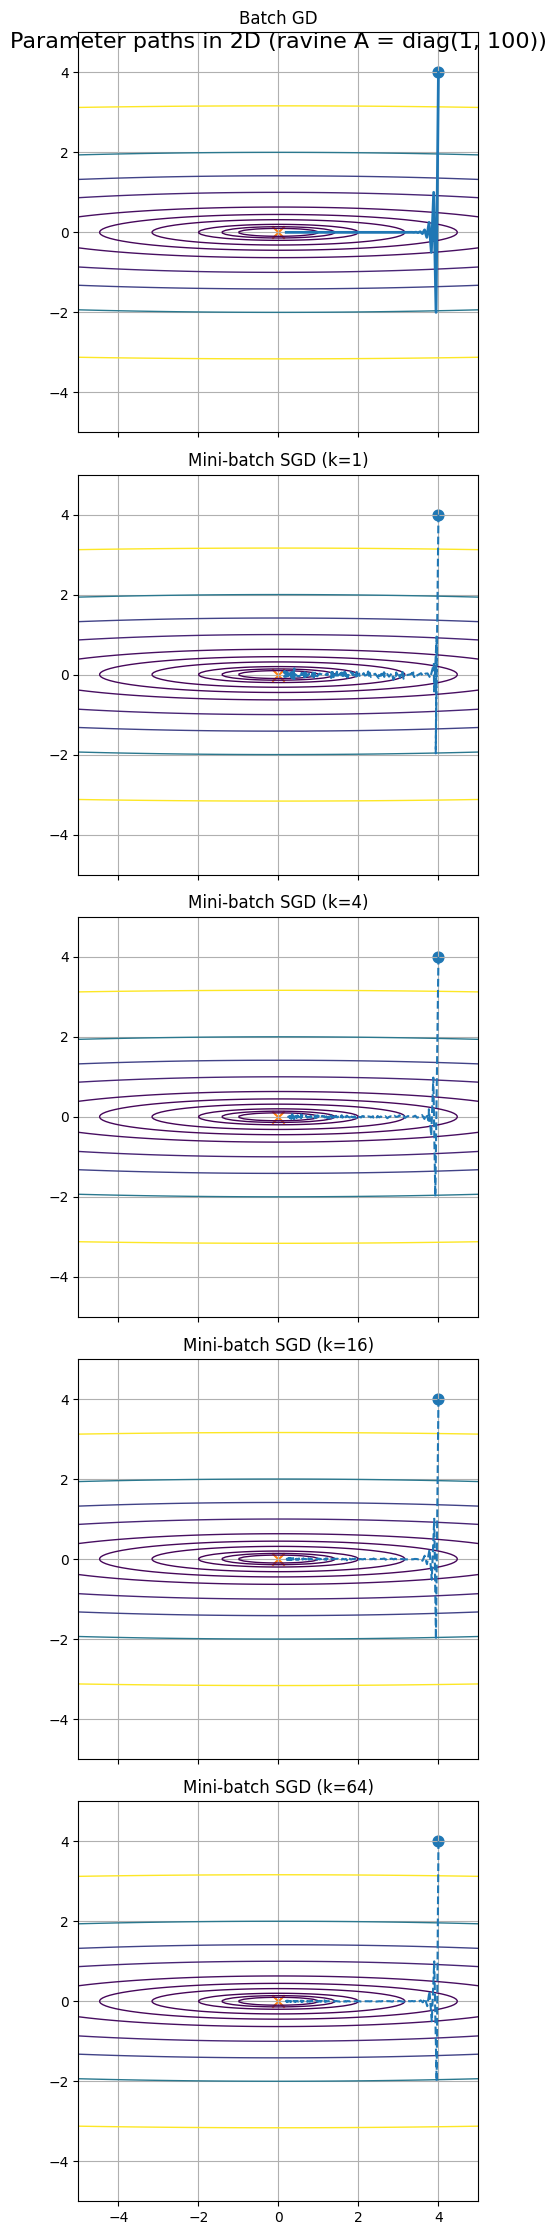

In [7]:
plot_paths(results)

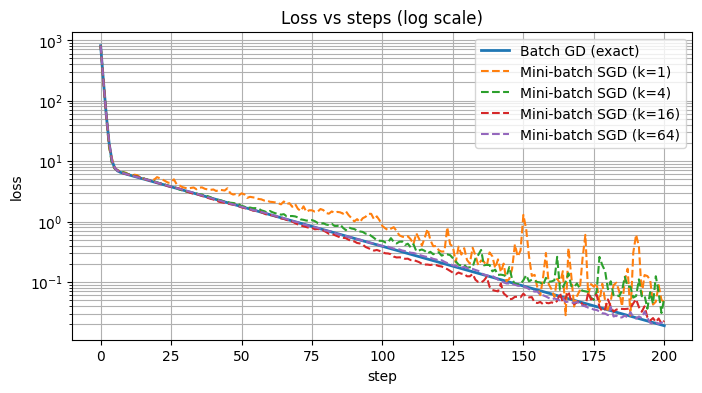

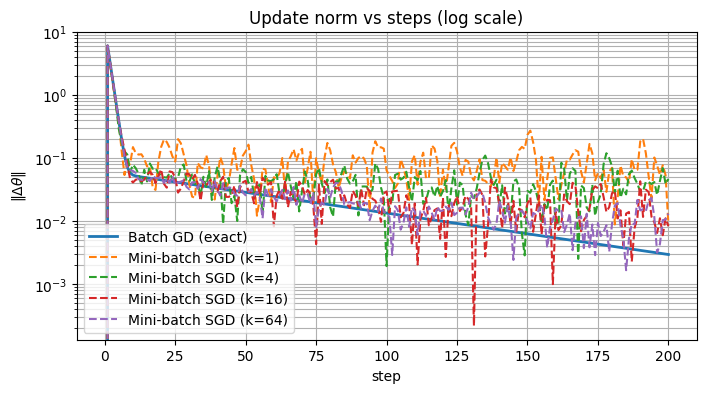

In [8]:
def plot_curves(results):
    steps = jnp.arange(results["gd"]["losses"].shape[0])
    gd_losses = results["gd"]["losses"]
    gd_upd = results["gd"]["upd_norms"]
    mb = results["minibatch"]

    # Loss vs steps (log scale helps)
    plt.figure(figsize=(8,4))
    plt.plot(steps, gd_losses, linewidth=2, label="Batch GD (exact)")
    for k, d in mb.items():
        plt.plot(steps, d["losses"], linestyle="--", linewidth=1.5, label=f"Mini-batch SGD (k={k})")
    plt.yscale("log")
    plt.title("Loss vs steps (log scale)")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.grid(True, which="both")
    plt.legend()
    plt.show()

    # Update norm vs steps
    plt.figure(figsize=(8,4))
    plt.plot(steps, gd_upd, linewidth=2, label="Batch GD (exact)")
    for k, d in mb.items():
        plt.plot(steps, d["upd_norms"], linestyle="--", linewidth=1.5, label=f"Mini-batch SGD (k={k})")
    plt.yscale("log")
    plt.title("Update norm vs steps (log scale)")
    plt.xlabel("step")
    plt.ylabel(r"$\|\Delta \theta\|$")
    plt.grid(True, which="both")
    plt.legend()
    plt.show()

plot_curves(results)

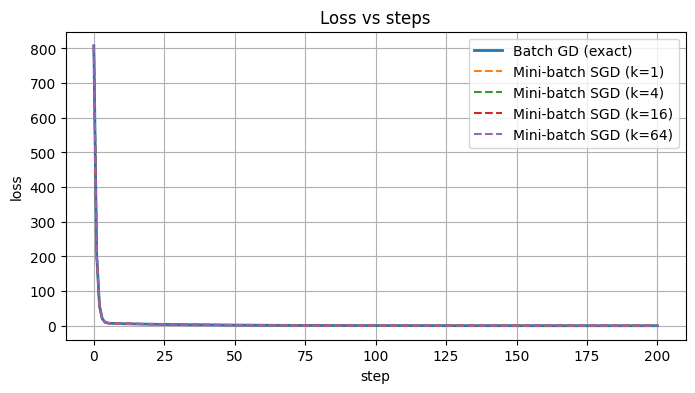

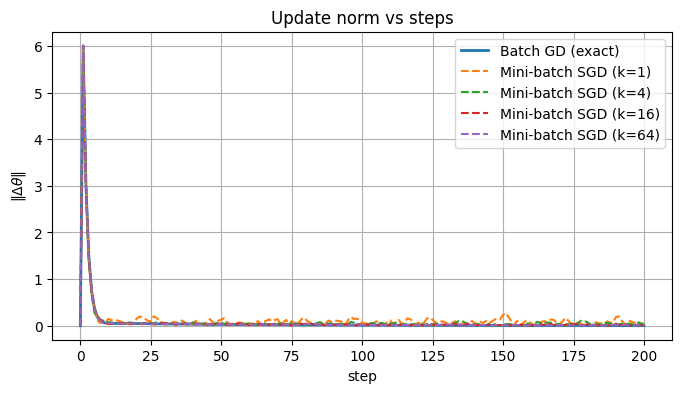

In [39]:
def plot_curves(results):
    steps = jnp.arange(results["gd"]["losses"].shape[0])
    gd_losses = results["gd"]["losses"]
    gd_upd = results["gd"]["upd_norms"]
    mb = results["minibatch"]

    # Loss vs steps (linear scale)
    plt.figure(figsize=(8,4))
    plt.plot(steps, gd_losses, linewidth=2, label="Batch GD (exact)")
    for k, d in mb.items():
        plt.plot(steps, d["losses"], linestyle="--", linewidth=1.5,
                 label=f"Mini-batch SGD (k={k})")
    plt.title("Loss vs steps")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Update norm vs steps (linear scale)
    plt.figure(figsize=(8,4))
    plt.plot(steps, gd_upd, linewidth=2, label="Batch GD (exact)")
    for k, d in mb.items():
        plt.plot(steps, d["upd_norms"], linestyle="--", linewidth=1.5,
                 label=f"Mini-batch SGD (k={k})")
    plt.title("Update norm vs steps")
    plt.xlabel("step")
    plt.ylabel(r"$\|\Delta \theta\|$")
    plt.grid(True)
    plt.legend()
    plt.show()


plot_curves(results)